In [1]:
import clip
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 1. Zero-Shot Classification on STL-10

In [2]:
model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()

100%|███████████████████████████████████████| 338M/338M [01:03<00:00, 5.54MiB/s]


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_fe

In [6]:
stl10_test = torchvision.datasets.STL10(root="./data", split="test", download=True, transform=preprocess)

test_loader = DataLoader(stl10_test, batch_size=64, shuffle=False, num_workers=0)

100%|██████████| 2.64G/2.64G [36:31<00:00, 1.20MB/s]   


In [7]:
stl10_test.classes

['airplane',
 'bird',
 'car',
 'cat',
 'deer',
 'dog',
 'horse',
 'monkey',
 'ship',
 'truck']

In [13]:
stl10_classes = stl10_test.classes

# Plain Labels
prompts_plain = [
    f"{c}" for c in stl10_classes
]

# Photo Prompt
prompts_photo = [
    f"a photo of a {c}" for c in stl10_classes
]

# Descriptive Prompts
prompts_descriptive = [
    "a photo of an airplane flying in the sky",
    "a photo of a bird with wings",
    "a photo of a car on the road",
    "a photo of a cat, a pet animal",
    "a photo of a deer in nature",
    "a photo of a dog, a pet animal",
    "a photo of a horse in a field",
    "a photo of a monkey, a primate",
    "a photo of a ship on the water",
    "a photo of a truck, a large vehicle",
]

In [14]:
def encode_text_prompts(prompts):
    """encode a list of text prompts into normalized embeddings"""
    text_tokens = clip.tokenize(prompts).to(device)
    with torch.no_grad():
        text_features = model.encode_text(text_tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)
    return text_features


def evaluate_zero_shot(loader, text_features):
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            image_features = model.encode_image(images)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

            similarity = image_features @ text_features.T

            predictions = similarity.argmax(dim=-1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return correct / total

In [15]:
tf_plain       = encode_text_prompts(prompts_plain)
tf_photo       = encode_text_prompts(prompts_photo)
tf_descriptive = encode_text_prompts(prompts_descriptive)

acc_plain       = evaluate_zero_shot(test_loader, tf_plain)
acc_photo       = evaluate_zero_shot(test_loader, tf_photo)
acc_descriptive = evaluate_zero_shot(test_loader, tf_descriptive)

print(f"Plain labels:       {acc_plain:.4f}")
print(f"Photo prompt:       {acc_photo:.4f}")
print(f"Descriptive prompt: {acc_descriptive:.4f}")

Plain labels:       0.9626
Photo prompt:       0.9735
Descriptive prompt: 0.9169


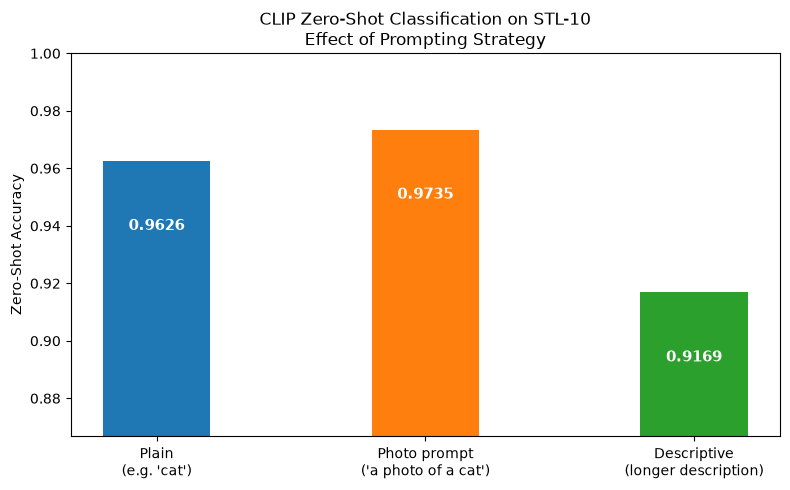

In [16]:
import matplotlib.pyplot as plt

strategies = ["Plain\n(e.g. 'cat')", "Photo prompt\n('a photo of a cat')", "Descriptive\n(longer description)"]
accuracies = [acc_plain, acc_photo, acc_descriptive]
colors = ["tab:blue", "tab:orange", "tab:green"]

plt.figure(figsize=(8, 5))
bars = plt.bar(strategies, accuracies, color=colors, width=0.4)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() - 0.02,
             f"{acc:.4f}",
             ha="center", va="top",
             fontsize=11, color="white", fontweight="bold")

plt.ylim(min(accuracies) - 0.05, 1.0)
plt.ylabel("Zero-Shot Accuracy")
plt.title("CLIP Zero-Shot Classification on STL-10\nEffect of Prompting Strategy")
plt.tight_layout()
plt.savefig("clip_zeroshot_stl10.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Exploring the Modality Gap

In [65]:
num_samples = 100

stl10_data = torchvision.datasets.STL10(root="./data",split="train", download=True, transform=preprocess,)

sample_indices = np.random.default_rng(42).choice(len(stl10_data), size=num_samples, replace=False)

images, labels = zip(*(stl10_data[index] for index in sample_indices))
image_inputs = torch.stack(images).to(device)
labels = np.asarray(labels)
class_names = stl10_data.classes

print(f"Using {len(labels)} images and {len(class_names)} text labels.")

Using 100 images and 10 text labels.


In [66]:
with torch.no_grad():
    image_features_raw = model.encode_image(image_inputs).float()

image_features_normalized = image_features_raw / image_features_raw.norm(dim=-1, keepdim=True)

text_prompts = [f"a photo of a {class_name}" for class_name in class_names]
text_tokens = clip.tokenize(text_prompts).to(device)

with torch.no_grad():
    text_features_raw = model.encode_text(text_tokens).float()

text_features_normalized = text_features_raw / text_features_raw.norm(dim=-1, keepdim=True)

print("Image embeddings:", image_features_raw.shape)
print("Text embeddings:", text_features_raw.shape)
print(f"Mean raw image norm: {image_features_raw.norm(dim=1).mean():.2f}")
print(f"Mean raw text norm:  {text_features_raw.norm(dim=1).mean():.2f}")

Image embeddings: torch.Size([100, 512])
Text embeddings: torch.Size([10, 512])
Mean raw image norm: 10.59
Mean raw text norm:  10.17


In [67]:
from sklearn.manifold import TSNE

def project_2d(image_embeddings, text_embeddings):
    combined_embeddings = torch.cat(
        [image_embeddings, text_embeddings]
    ).cpu().numpy()

    return TSNE(
        n_components=2,
        perplexity=25,
        init="pca",
        learning_rate="auto",
        random_state=42,
    ).fit_transform(combined_embeddings)

raw_projection = project_2d(image_features_raw, text_features_raw)
normalized_projection = project_2d(
    image_features_normalized,
    text_features_normalized,
)

C:\Users\Taha\AppData\Local\Temp\ipykernel_26508\3051248840.py:22: UserWarning: You passed an edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axis.scatter(


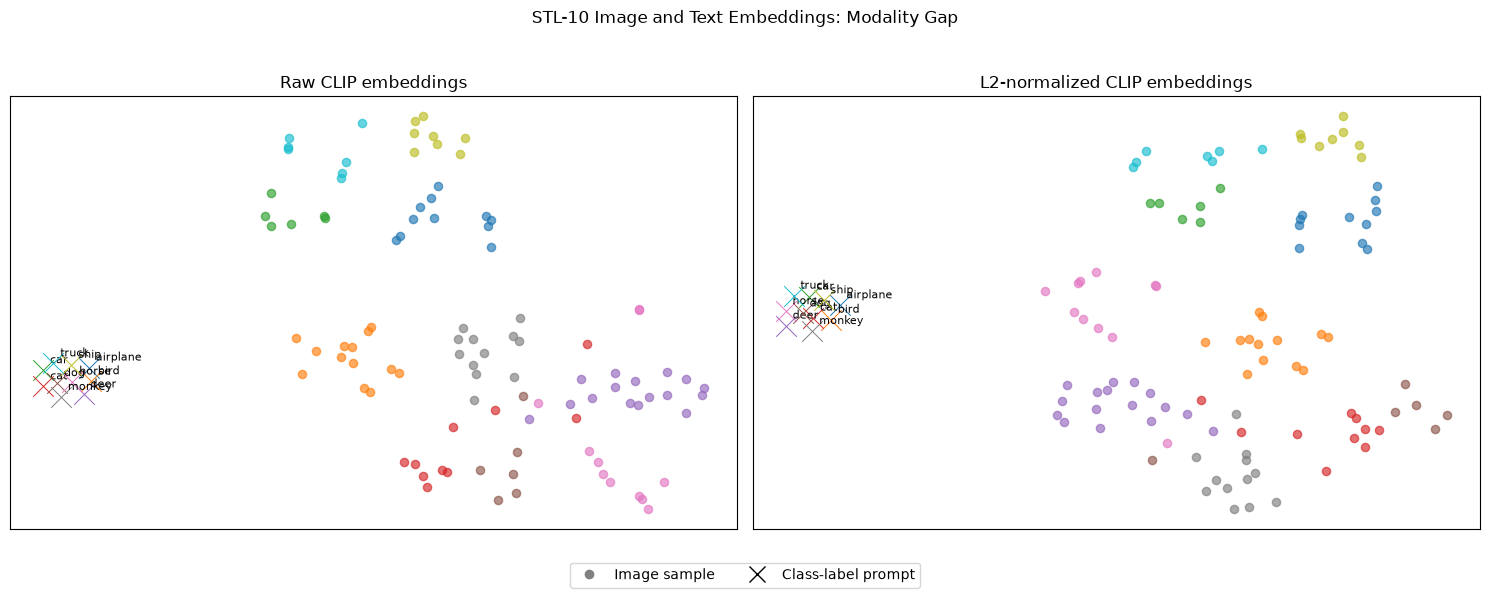

In [68]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt

def plot_projection(axis, projection, title):
    image_points = projection[:num_samples]
    text_points = projection[num_samples:]
    colors = plt.cm.tab10(np.arange(len(class_names)))

    for class_index, class_name in enumerate(class_names):
        class_mask = labels == class_index

        # Circles = image embeddings
        axis.scatter(
            image_points[class_mask, 0],
            image_points[class_mask, 1],
            color=colors[class_index],
            alpha=0.65,
            s=35,
        )

        # Stars = the ten text-label embeddings
        axis.scatter(
            text_points[class_index, 0],
            text_points[class_index, 1],
            color=colors[class_index],
            marker="x",
            edgecolor="black",
            linewidth=0.7,
            s=220,
            zorder=3,
        )

        axis.annotate(
            class_name,
            text_points[class_index],
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
        )

    axis.set_title(title)
    axis.set_xticks([])
    axis.set_yticks([])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

plot_projection(axes[0], raw_projection, "Raw CLIP embeddings")
plot_projection(axes[1], normalized_projection, "L2-normalized CLIP embeddings")

fig.legend(
    handles=[
        Line2D([0], [0], marker="o", color="w", label="Image sample",
               markerfacecolor="gray", markersize=8),
        Line2D([0], [0], marker="x", color="w", label="Class-label prompt",
               markerfacecolor="gray", markeredgecolor="black", markersize=12),
    ],
    loc="lower center",
    ncol=2,
)

fig.suptitle("STL-10 Image and Text Embeddings: Modality Gap", y=0.97)
plt.tight_layout(rect=(0, 0.08, 1, 0.94))
plt.savefig("clip_stl10_modality_gap.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Bridging the Modality Gap

In [69]:
from scipy.linalg import orthogonal_procrustes

label_indices = torch.tensor(labels, device=device)
paired_text_features = text_features_normalized[label_indices]

In [71]:
R, procrustes_error = orthogonal_procrustes(image_features_normalized.cpu().numpy(), paired_text_features.cpu().numpy())

R_tensor = torch.from_numpy(R).to(device=device, dtype=torch.float32)

aligned_image_features = image_features_normalized @ R_tensor
aligned_image_features = aligned_image_features / aligned_image_features.norm(dim=-1, keepdim=True)

print(f"Rotation Matrix Shape: {R_tensor.shape}")
print(f"Procrustes Score: {procrustes_error:.4f}")

Rotation Matrix Shape: torch.Size([512, 512])
Procrustes Score: 88.1661


In [72]:
before_similarity = (image_features_normalized * paired_text_features).sum(dim=1).mean()
after_similarity = (aligned_image_features * paired_text_features).sum(dim=1).mean()

print(f"Mean matching similarity before: {before_similarity:.4f}")
print(f"Mean matching similarity after: {after_similarity:.4f}")

Mean matching similarity before: 0.2701
Mean matching similarity after: 0.8816


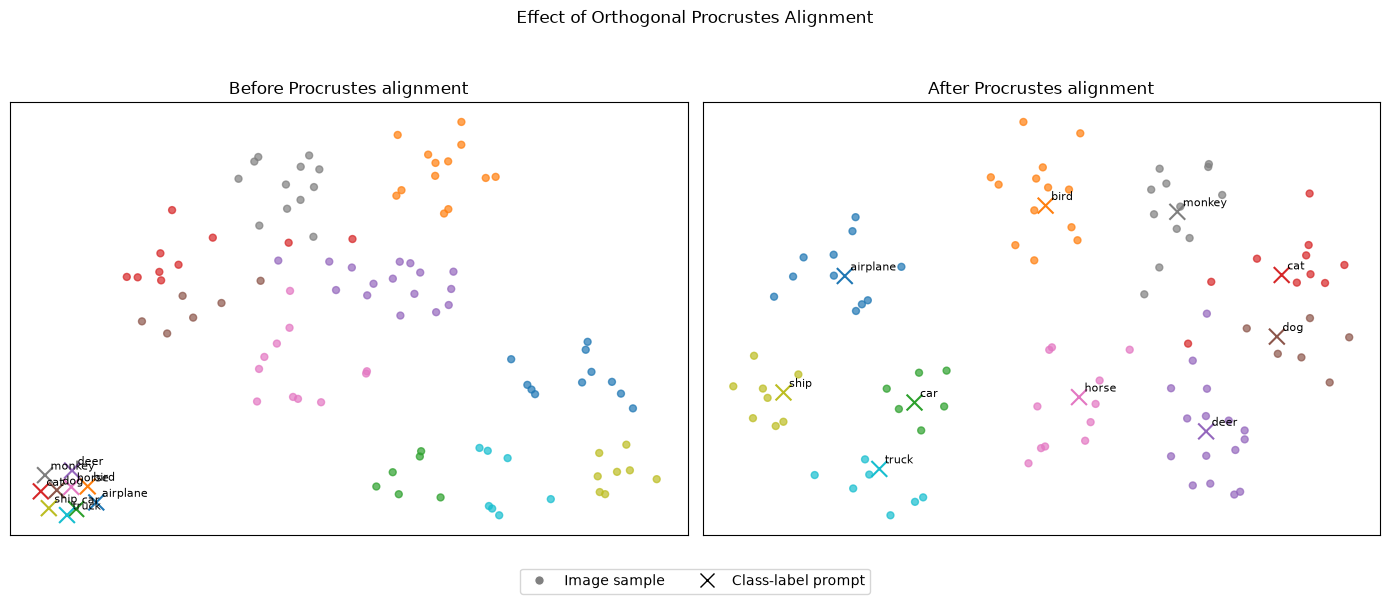

In [73]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def create_projection(image_embeddings, text_embeddings):
    embeddings = torch.cat([image_embeddings, text_embeddings]).cpu().numpy()

    return TSNE(
        n_components=2,
        perplexity=30,
        init="pca",
        learning_rate="auto",
        random_state=42,
    ).fit_transform(embeddings)

before_projection = create_projection(
    image_features_normalized,
    text_features_normalized,
)

after_projection = create_projection(
    aligned_image_features,
    text_features_normalized,
)

def draw_plot(axis, projection, title):
    image_points = projection[:num_samples]
    text_points = projection[num_samples:]

    axis.scatter(
        image_points[:, 0],
        image_points[:, 1],
        c=labels,
        cmap="tab10",
        s=25,
        alpha=0.7,
    )

    axis.scatter(
        text_points[:, 0],
        text_points[:, 1],
        c=np.arange(len(class_names)),
        cmap="tab10",
        marker="x",
        s=130,
        linewidths=1.5,
        zorder=3,
    )

    for class_index, class_name in enumerate(class_names):
        axis.annotate(
            class_name,
            text_points[class_index],
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8,
        )

    axis.set_title(title)
    axis.set_xticks([])
    axis.set_yticks([])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

draw_plot(axes[0], before_projection, "Before Procrustes alignment")
draw_plot(axes[1], after_projection, "After Procrustes alignment")

fig.legend(
    handles=[
        Line2D([0], [0], marker="o", color="w", label="Image sample",
               markerfacecolor="gray", markersize=7),
        Line2D([0], [0], marker="x", color="black", label="Class-label prompt",
               markersize=10, linewidth=0),
    ],
    loc="lower center",
    ncol=2,
)

fig.suptitle("Effect of Orthogonal Procrustes Alignment", y=0.98)
plt.tight_layout(rect=(0, 0.08, 1, 0.94))
plt.savefig("clip_procrustes_alignment.png", dpi=150, bbox_inches="tight")
plt.show()

In [75]:
def evaluate_aligned_zero_shot(loader, text_features, rotation_matrix):
    correct = 0
    total = 0

    # Match the float32 dtype used by aligned image features.
    text_features = text_features.to(device=device, dtype=torch.float32)

    with torch.no_grad():
        for images, batch_labels in loader:
            images = images.to(device)
            batch_labels = batch_labels.to(device)

            image_features = model.encode_image(images).float()
            image_features = (
                image_features
                / image_features.norm(dim=-1, keepdim=True)
            )

            aligned_features = image_features @ rotation_matrix
            aligned_features = (
                aligned_features
                / aligned_features.norm(dim=-1, keepdim=True)
            )

            similarity = aligned_features @ text_features.T
            predictions = similarity.argmax(dim=1)

            correct += (predictions == batch_labels).sum().item()
            total += batch_labels.size(0)

    return correct / total


aligned_accuracy = evaluate_aligned_zero_shot(
    test_loader,
    tf_photo,
    R_tensor,
)

print(f"Original photo-prompt accuracy: {acc_photo:.4f}")
print(f"Aligned photo-prompt accuracy:  {aligned_accuracy:.4f}")
print(f"Accuracy change:                {aligned_accuracy - acc_photo:+.4f}")

Original photo-prompt accuracy: 0.9735
Aligned photo-prompt accuracy:  0.9627
Accuracy change:                -0.0108
